<a href="https://colab.research.google.com/github/katzemelli/thesis-edit-distance-nn/blob/main/notebooks/colab4_PSO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Colab 4 — Particle Swarm Optimization for weight training

In colabs 1-3 we established that:
- The Levenshtein NN from [the paper](https://ieeexplore.ieee.org/document/11272136) gets stuck in a local solution for `DESIRE='01'`
- Swapping activations (SiLU, Leaky ReLU) doesn't help — the gradient is **structurally zero** due to the frozen analytical weight configuration, not just because of ReLU clipping

**Solution:** Replace gradient-based optimization (SGD/Adam) with Particle Swarm Optimization (PSO) for the trainable `for_gen_dense_*` weights. PSO is gradient-free — it explores the weight space using a swarm of candidate solutions, completely bypassing the dead gradient problem.

**PSO overview:**
- Each **particle** is a candidate set of `for_gen_dense_*` weights
- Each particle has a **position** (weight values) and **velocity**
- Particles are attracted toward their own best-known position (**pbest**) and the swarm's global best (**gbest**)
- Update rules: `v = w*v + c1*r1*(pbest - pos) + c2*r2*(gbest - pos)`, then `pos = pos + v`

**Test plan:**
1. Train with `DESIRE='11'` — should converge (sanity check)
2. Train with `DESIRE='01'` — the case that gradient descent fails on

In [1]:
import os

!git clone https://github.com/katzemelli/thesis-edit-distance-nn.git

os.chdir('/content/thesis-edit-distance-nn')

!ls sampledata/

Cloning into 'thesis-edit-distance-nn'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 83 (delta 46), reused 43 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (83/83), 289.68 KiB | 1.68 MiB/s, done.
Resolving deltas: 100% (46/46), done.
desired_length_2_levenshtein_2.csv  predtime_length_10_2_levenshtein.csv
desired_length_2_levenshtein_3.csv  predtime_length_5_4_levenshtein.csv
desired_length_2_levenshtein.csv    predtime_length_5_levenshtein.csv


In [2]:
!pip install tensorflow ml_dtypes --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 16.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-pubsub 2.36.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>

In [3]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [4]:
import random
import time
import os
import math
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Activation, Input, add, Lambda, Reshape, concatenate, Flatten

### Architecture (identical to the original paper — ReLU, analytical weights)

In [5]:
def transform_seqs_to_input(seqA, seqB):
    matching_pairs = []
    input_length_x = 0

    matching_pairs.append([int(seqA[0]), int(seqB[0])])
    if len(seqA) == 1 and len(seqB) == 1:
        return matching_pairs
    else:
        input_length_x = len(seqA)
        match_layers_i = (input_length_x * 2) - 1

    start_i = 1
    end_i = 2

    for l in range(match_layers_i):
        if l < input_length_x - 1:
            i, j = [*reversed(range(0, end_i))], [*range(0, end_i)]
            for n in range(len(i)):
                if j[n] < len(seqB):
                    pair = [int(seqA[i[n]]), int(seqB[j[n]])]
                    matching_pairs.append(pair)
            end_i += 1
        else:
            i, j = [*reversed(range(start_i, input_length_x))], [*range(start_i, input_length_x)]
            for n in range(len(i)):
                if j[n] < len(seqB):
                    pair = [int(seqA[i[n]]), int(seqB[j[n]])]
                    matching_pairs.append(pair)
            start_i += 1
            if start_i > len(seqB):
                break

    return matching_pairs


def transform_input_for_generate(input):
    x = []
    y = []
    for pair in input:
        x.append(pair[0])
        y.append(pair[1])
    return [x, y]

In [6]:
def matching_module():
    epsilon = 1

    model = Sequential()
    model.add(Dense(units=2, activation='relu', use_bias=True, input_shape=(2,)))
    model.add(Dense(units=2, activation='relu', use_bias=True))
    model.add(Dense(units=1, activation='relu', use_bias=True))

    w1 = model.layers[0].get_weights()
    w1[0][0][0], w1[0][0][1] = 1.0, -1.0
    w1[0][1][0], w1[0][1][1] = -1.0, 1.0
    w1[1][0], w1[1][1] = 0, 0
    w2 = model.layers[1].get_weights()
    w2[0][0][0], w2[0][0][1] = 1.0, 1.0
    w2[0][1][0], w2[0][1][1] = 1.0, 1.0
    w2[1][0], w2[1][1] = epsilon, -1 * epsilon
    w3 = model.layers[2].get_weights()
    w3[0][0][0], w3[0][1][0] = (1.0/epsilon), -1.0 * (1.0/epsilon)
    w3[1][0] = -1

    model.layers[0].set_weights(w1)
    model.layers[1].set_weights(w2)
    model.layers[2].set_weights(w3)

    model.trainable = False
    return model


def min_module(i, j, k):
    input = Input(shape=(2,))
    x = Dense(2, activation='relu', use_bias=True)(input)
    combined = concatenate([x, input])

    layer_name = 'result_pixel_' + str(i) + str(j) + '_' + str(k)
    z = Dense(1, activation='relu', use_bias=True, name=layer_name)(combined)
    model = Model(inputs=input, outputs=z)

    w1 = model.layers[1].get_weights()
    w1[0][0], w1[0][1] = [-1.0, 1.0], [1.0, -1.0]
    w2 = model.layers[3].get_weights()
    w2[0][0], w2[0][1], w2[0][2], w2[0][3] = -0.5, -0.5, 0.5, 0.5

    model.layers[1].set_weights(w1)
    model.layers[3].set_weights(w2)

    model.trainable = False
    return model


def minimum(i, j):
    input = Input(shape=(3,))
    comp1_pair = Lambda(lambda x: x[:, :2], output_shape=(2,))(input)
    comp2_input = Lambda(lambda x: x[:, 2:], output_shape=(1,))(input)

    m = min_module(i, j, 1)(comp1_pair)
    comp2_pair = concatenate([comp2_input, m])
    output = min_module(i, j, 2)(comp2_pair)

    model = Model(inputs=input, outputs=output)
    model.trainable = False
    return model

In [7]:
def align_model_for_N(seq_length_x, seq_length_y, matching_pair_number):
    input = Input(shape=(2, matching_pair_number), name='input')

    y = Lambda(lambda t: t[:, 1, :], output_shape=(matching_pair_number,))(input)
    x = Lambda(lambda t: t[:, 0, :], output_shape=(matching_pair_number,))(input)

    out = {}
    start_i = 0
    step = 2
    for i in range(seq_length_y):
        a = start_i
        layername = 'for_gen_dense_' + str(i + 1)
        y_slice = Lambda(lambda t, a=a: t[:, a:a+1], output_shape=(1,))(y)
        # I am thinking this is where the problem of the dying gradient happens:
        # since Dense(1,relu..) = relu(w_i*y_slice) and if y_slice=0 it all becomes 0 no matter what the rest of
        # NN does
        # PSO takes AGES to compute??
        # maybe a naiv idea but instead of using a binary alphabet of 0 & 1 use 2 & 1 to avoid mulitplying by 0
        z = Dense(1, activation='relu', name=layername, use_bias=False)(y_slice)
        out[layername] = z
        start_i += step
        step += 1

    pair_i = 1
    calc_layer = (seq_length_x * 2) - 1
    test_dict = {}

    y_dense_layer_name = 'for_gen_dense_1'
    densed_y = out[y_dense_layer_name]
    x_char = Lambda(lambda t: t[:, 0:1], output_shape=(1,))(x)

    debug_name = 'matching_debug_1'
    pair_11 = concatenate([x_char, densed_y], name=debug_name)

    ext_gaps = Dense(2, activation='relu', name='first_calc_gap_layer')(pair_11)

    min1 = min_module(1, 1, 1)(ext_gaps)
    matching1 = matching_module()(pair_11)
    combined = concatenate([min1, matching1])
    z = min_module(1, 1, 2)(combined)
    result_pixel_11 = concatenate([ext_gaps, z], name='input_pixel_1_1')

    pair_i = 2

    if seq_length_x == 1 and seq_length_y == 1:
        output = z
        return Model(inputs=input, outputs=output)
    else:
        test_dict['input_pixel_1_1'] = result_pixel_11
        test_dict['result_pixel_1_1'] = z

        comp_i_val, comp_j_val = 1, 2
        start_sentinel, end_sentinel = 1, 2
        unbalance_flag = True

        for calc_layer_i in range(calc_layer):
            if calc_layer_i < seq_length_x - 1:
                comp_i_val, comp_j_val = start_sentinel, end_sentinel
                while comp_i_val <= end_sentinel:
                    if comp_i_val <= seq_length_y:
                        input_layer_name = 'input_' + str(comp_i_val) + '_' + str(comp_j_val)
                        before_input_layer_name = 'before_input_' + str(comp_i_val) + '_' + str(comp_j_val)

                        c = pair_i
                        y_i = comp_i_val
                        y_dense_layer_name = 'for_gen_dense_' + str(y_i)
                        densed_y = out[y_dense_layer_name]

                        x_char = Lambda(lambda t, c=c: t[:, c-1:c], output_shape=(1,))(x)

                        debug_name = 'matching_debug_' + str(c)
                        pair = concatenate([x_char, densed_y], name=debug_name)
                        matching = matching_module()(pair)

                        if comp_i_val == 1:
                            previous_input_pixel_name = 'input_pixel_' + str(comp_i_val) + '_' + str(comp_j_val - 1)
                            previous_result_pixel_name = 'result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val - 1)
                            previous_input = test_dict[previous_input_pixel_name]
                            previous_result = test_dict[previous_result_pixel_name]
                            g = Lambda(lambda t: t[:, 0:1], output_shape=(1,))(previous_input)
                            before_input = concatenate([g, previous_result, matching], name=before_input_layer_name)

                        elif comp_j_val == 1:
                            previous_input_pixel_name = 'input_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val)
                            previous_result_pixel_name = 'result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val)
                            previous_input = test_dict[previous_input_pixel_name]
                            previous_result = test_dict[previous_result_pixel_name]
                            g = Lambda(lambda t: t[:, 0:1], output_shape=(1,))(previous_input)
                            before_input = concatenate([g, previous_result, matching], name=before_input_layer_name)

                        else:
                            previous_result1 = test_dict['result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val - 1)]
                            previous_result2 = test_dict['result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val)]
                            previous_result3 = test_dict['result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val - 1)]
                            before_input = concatenate([previous_result1, previous_result2, previous_result3, matching], name=before_input_layer_name)

                        input_pixel = Dense(3, activation='relu', name=input_layer_name)(before_input)
                        result_pixel = minimum(comp_i_val, comp_j_val)(input_pixel)

                        test_dict['input_pixel_' + str(comp_i_val) + '_' + str(comp_j_val)] = input_pixel
                        test_dict['result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val)] = result_pixel

                        if unbalance_flag:
                            unbalance_flag = False

                    comp_i_val += 1
                    comp_j_val -= 1
                    pair_i += 1
                    if unbalance_flag:
                        pair_i -= 1
                    unbalance_flag = True

                if end_sentinel + 1 <= seq_length_x:
                    end_sentinel += 1

            else:
                start_sentinel += 1
                comp_i_val, comp_j_val = start_sentinel, end_sentinel

                while comp_i_val <= end_sentinel:
                    if comp_i_val <= seq_length_y:
                        before_input_layer_name = 'before_input_' + str(comp_i_val) + '_' + str(comp_j_val)
                        input_layer_name = 'input_' + str(comp_i_val) + '_' + str(comp_j_val)

                        c = pair_i
                        y_dense_layer_name = 'for_gen_dense_' + str(comp_i_val)
                        densed_y = out[y_dense_layer_name]

                        x_char = Lambda(lambda t, c=c: t[:, c-1:c], output_shape=(1,))(x)
                        debug_name = 'matching_debug_' + str(c)
                        pair = concatenate([x_char, densed_y], name=debug_name)
                        matching = matching_module()(pair)

                        previous_result1 = test_dict['result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val - 1)]
                        previous_result2 = test_dict['result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val)]
                        previous_result3 = test_dict['result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val - 1)]
                        before_input = concatenate([previous_result1, previous_result2, previous_result3, matching], name=before_input_layer_name)

                        input_pixel = Dense(3, activation='relu', name=input_layer_name)(before_input)
                        result_pixel = minimum(comp_i_val, comp_j_val)(input_pixel)

                        test_dict['input_pixel_' + str(comp_i_val) + '_' + str(comp_j_val)] = input_pixel
                        test_dict['result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val)] = result_pixel

                        if unbalance_flag:
                            unbalance_flag = False

                    comp_i_val += 1
                    comp_j_val -= 1
                    pair_i += 1
                    if unbalance_flag:
                        pair_i -= 1
                    unbalance_flag = True

                    if start_sentinel == end_sentinel:
                        return Model(inputs=input, outputs=result_pixel)

In [8]:
def set_weight_for_debug(model, seq_len_x, seq_len_y, matching_pair):
    """Set analytical weights on frozen layers. Does NOT set for_gen_dense weights — PSO handles those."""
    print('setting frozen weights ...')

    w = model.get_layer('first_calc_gap_layer').get_weights()
    w[0][0][0], w[0][0][1] = 0, 0
    w[0][1][0], w[0][1][1] = 0, 0
    w[1][0], w[1][1] = 2, 2
    model.get_layer('first_calc_gap_layer').set_weights(w)
    model.get_layer('first_calc_gap_layer').trainable = False

    if seq_len_x > 1:
        calc_layer = (seq_len_x * 2) - 1
        comp_i, comp_j = 1, 2
        start_sentinel, end_sentinel = 1, 2

        for calc_layer_i in range(calc_layer):
            if calc_layer_i < seq_len_x - 1:
                comp_i, comp_j = start_sentinel, end_sentinel
                while comp_i <= end_sentinel:
                    if comp_i <= seq_len_y:
                        input_layer_name = 'input_' + str(comp_i) + '_' + str(comp_j)
                        w = model.get_layer(input_layer_name).get_weights()
                        if comp_i == 1:
                            w[0][0][0], w[0][0][1], w[0][0][2] = 1, 0, 1
                            w[0][1][0], w[0][1][1], w[0][1][2] = 0, 1, 0
                            w[0][2][0], w[0][2][1], w[0][2][2] = 0, 0, 1
                            w[1][0], w[1][1], w[1][2] = 1, 1, -1
                        elif comp_j == 1:
                            w[0][0][0], w[0][0][1], w[0][0][2] = 1, 0, 1
                            w[0][1][0], w[0][1][1], w[0][1][2] = 0, 1, 0
                            w[0][2][0], w[0][2][1], w[0][2][2] = 0, 0, 1
                            w[1][0], w[1][1], w[1][2] = 1, 1, -1
                        else:
                            w[0][0][0], w[0][0][1], w[0][0][2] = 1, 0, 0
                            w[0][1][0], w[0][1][1], w[0][1][2] = 0, 1, 0
                            w[0][2][0], w[0][2][1], w[0][2][2] = 0, 0, 1
                            w[0][3][0], w[0][3][1], w[0][3][2] = 0, 0, 1
                            w[1][0], w[1][1], w[1][2] = 1, 1, 0

                        model.get_layer(input_layer_name).set_weights(w)
                        model.get_layer(input_layer_name).trainable = False

                    comp_i, comp_j = (comp_i + 1), (comp_j - 1)
                if end_sentinel + 1 <= seq_len_x:
                    end_sentinel += 1
            else:
                start_sentinel = start_sentinel + 1
                comp_i, comp_j = start_sentinel, end_sentinel

                while comp_i <= end_sentinel:
                    if comp_i <= seq_len_y:
                        input_layer_name = 'input_' + str(comp_i) + '_' + str(comp_j)
                        w = model.get_layer(input_layer_name).get_weights()
                        w[0][0][0], w[0][0][1], w[0][0][2] = 1, 0, 0
                        w[0][1][0], w[0][1][1], w[0][1][2] = 0, 1, 0
                        w[0][2][0], w[0][2][1], w[0][2][2] = 0, 0, 1
                        w[0][3][0], w[0][3][1], w[0][3][2] = 0, 0, 1
                        w[1][0], w[1][1], w[1][2] = 1, 1, 0
                        model.get_layer(input_layer_name).set_weights(w)
                        model.get_layer(input_layer_name).trainable = False

                    comp_i, comp_j = (comp_i + 1), (comp_j - 1)

### PSO implementation

In [9]:
def evaluate_fitness(model, weights_vector, n_weights, training_data):
    """
    Set the for_gen_dense weights from the particle position and compute MSE loss
    plus a binary regularization penalty: lambda * sum(min(w^2, (1-w)^2)).
    This penalty is minimized (=0) when each weight is exactly 0 or 1,
    and increases for any other value (always non-negative).
    """
    # Set weights from particle position
    for i in range(n_weights):
        lname = 'for_gen_dense_' + str(i + 1)
        w = model.get_layer(lname).get_weights()
        w[0][0][0] = weights_vector[i]
        model.get_layer(lname).set_weights(w)

    # Compute MSE over all training samples
    total_loss = 0.0
    for x_str, y_str, true_score in training_data:
        inp = transform_seqs_to_input(x_str, y_str)
        inp = transform_input_for_generate(inp)
        inp = tf.constant([inp])
        pred = model(inp, training=False)
        total_loss += float((true_score - pred[0][0]) ** 2)

    mse = total_loss / len(training_data)

    # Binary regularization: min(w^2, (1-w)^2) = 0 at w in {0, 1}, always >= 0
    binary_penalty = sum(min(wi**2, (1 - wi)**2) for wi in weights_vector)

    return mse + LAMBDA_BINARY * binary_penalty


def pso_optimize(model, n_weights, training_data,
                 n_particles=20, n_iterations=50,
                 w_inertia=0.7, c1=1.5, c2=1.5,
                 pos_min=-0.5, pos_max=1.5,
                 seed=None):
    """
    Particle Swarm Optimization for the for_gen_dense weights.

    Parameters:
        n_particles:  number of candidate solutions in the swarm
        n_iterations: number of PSO iterations
        w_inertia:    inertia weight (controls momentum)
        c1:           cognitive coefficient (personal best attraction)
        c2:           social coefficient (attraction to global best)
        pos_min/max:  search space bounds
    """
    if seed is not None:
        np.random.seed(seed)

    dim = n_weights

    # Initialize particles: random positions in [pos_min, pos_max], small random velocities
    positions = np.random.uniform(pos_min, pos_max, (n_particles, dim))
    velocities = np.random.uniform(-0.1, 0.1, (n_particles, dim))

    # Evaluate initial fitness
    fitness = np.array([evaluate_fitness(model, pos, dim, training_data) for pos in positions])

    # Personal bests
    pbest_positions = positions.copy()
    pbest_fitness = fitness.copy()

    # Global best
    gbest_idx = np.argmin(fitness)
    gbest_position = positions[gbest_idx].copy()
    gbest_fitness = fitness[gbest_idx]

    # Tracking for visualization
    gbest_history = [gbest_position.copy()]
    gbest_loss_history = [gbest_fitness]
    all_positions_history = [positions.copy()]

    print(f'Iteration 0 | best loss: {gbest_fitness:.6f} | best weights: {gbest_position}')

    for iteration in range(1, n_iterations + 1):
        r1 = np.random.uniform(0, 1, (n_particles, dim))
        r2 = np.random.uniform(0, 1, (n_particles, dim))

        # Update velocities
        velocities = (w_inertia * velocities
                      + c1 * r1 * (pbest_positions - positions)
                      + c2 * r2 * (gbest_position - positions))

        # Update positions
        positions = positions + velocities

        # Clamp to search bounds
        positions = np.clip(positions, pos_min, pos_max)

        # Evaluate fitness
        fitness = np.array([evaluate_fitness(model, pos, dim, training_data) for pos in positions])

        # Update personal bests
        improved = fitness < pbest_fitness
        pbest_positions[improved] = positions[improved]
        pbest_fitness[improved] = fitness[improved]

        # Update global best
        min_idx = np.argmin(pbest_fitness)
        if pbest_fitness[min_idx] < gbest_fitness:
            gbest_position = pbest_positions[min_idx].copy()
            gbest_fitness = pbest_fitness[min_idx]

        gbest_history.append(gbest_position.copy())
        gbest_loss_history.append(gbest_fitness)
        all_positions_history.append(positions.copy())

        if iteration % 10 == 0 or iteration == 1:
            print(f'Iteration {iteration} | best loss: {gbest_fitness:.6f} | best weights: {gbest_position}')

    # Set model to best-found weights
    for i in range(dim):
        lname = 'for_gen_dense_' + str(i + 1)
        w = model.get_layer(lname).get_weights()
        w[0][0][0] = gbest_position[i]
        model.get_layer(lname).set_weights(w)

    return {
        'gbest_position': gbest_position,
        'gbest_fitness': gbest_fitness,
        'gbest_history': gbest_history,
        'gbest_loss_history': gbest_loss_history,
        'all_positions_history': all_positions_history
    }

In [10]:
def load_training_data(filename):
    """Load CSV into list of (x_str, y_str, true_score) tuples."""
    data = []
    with open(filename, 'r') as f:
        for line in f:
            sp = line.strip().split(',')
            data.append((sp[0], sp[1], int(sp[2])))
    return data

### Plotting

In [11]:
def plot_pso_weights(gbest_history, desire, title=''):
    """Plot gbest weight trajectory over iterations."""
    iterations = len(gbest_history)
    x = list(range(iterations))

    color_cycle = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                   '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    markers = ['o', 's', '^', 'v', '*']
    plt.figure(figsize=(18, 10), dpi=100)

    weights_over_time = np.array(gbest_history).T
    for w_i, w_vals in enumerate(weights_over_time):
        m = markers[w_i % len(markers)]
        plt.plot(x, w_vals, marker=m, label=f'weight{w_i+1}', color=color_cycle[w_i])
        plt.hlines(desire[w_i], 0, iterations - 1, color=color_cycle[w_i], linestyles='dotted')

    plt.xlabel('PSO iteration')
    plt.ylabel('weight')
    plt.ylim(-0.5, 1.5)
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=10)
    plt.show()


def plot_pso_loss(loss_history, title=''):
    """Plot global best loss over iterations."""
    plt.figure(figsize=(12, 5), dpi=100)
    plt.plot(loss_history, marker='o', markersize=3)
    plt.xlabel('PSO iteration')
    plt.ylabel('MSE loss (gbest)')
    plt.ylim(bottom=0)
    plt.title(title)
    plt.show()

### PSO configuration

In [12]:
# PSO hyperparameters
N_PARTICLES = 20      # swarm size
N_ITERATIONS = 50     # number of PSO iterations
W_INERTIA = 0.7       # inertia weight — higher = more exploration
C1 = 1.5              # cognitive coefficient (personal best attraction)
C2 = 1.5              # social coefficient (global best attraction)
POS_MIN = -0.5        # search space lower bound
POS_MAX = 1.5         # search space upper bound
SEED = 42

# Binary regularization: penalizes weights that aren't 0 or 1
# fitness = MSE + LAMBDA_BINARY * sum(w * (1-w))
# w*(1-w) = 0 at w=0 or w=1, max 0.25 at w=0.5
LAMBDA_BINARY = 0.5

### Experiment 1: DESIRE='11' (sanity check — should converge)

In [13]:
data_11 = load_training_data('/content/thesis-edit-distance-nn/sampledata/desired_length_2_levenshtein_2.csv')

# Get sequence dimensions from first sample
x0, y0, _ = data_11[0]
pairs_11 = transform_seqs_to_input(x0, y0)
SEQ_LEN_X_11 = len(x0)
SEQ_LEN_Y_11 = len(y0)
PAIRS_LEN_11 = len(pairs_11)

# Build model and set frozen weights
model_11 = align_model_for_N(SEQ_LEN_X_11, SEQ_LEN_Y_11, PAIRS_LEN_11)
set_weight_for_debug(model_11, SEQ_LEN_X_11, SEQ_LEN_Y_11, PAIRS_LEN_11)

print(f'Search space: {SEQ_LEN_Y_11} weights')
print(f'Training samples: {len(data_11)}')
print(f'Target weights (DESIRE): [1, 1]')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


setting frozen weights ...
Search space: 2 weights
Training samples: 4
Target weights (DESIRE): [1, 1]


In [14]:
result_11 = pso_optimize(
    model_11, SEQ_LEN_Y_11, data_11,
    n_particles=N_PARTICLES, n_iterations=N_ITERATIONS,
    w_inertia=W_INERTIA, c1=C1, c2=C2,
    pos_min=POS_MIN, pos_max=POS_MAX,
    seed=SEED
)

print(f"\nFinal weights: {result_11['gbest_position']}")
print(f"Final loss: {result_11['gbest_fitness']:.6f}")

Iteration 0 | best loss: 0.139371 | best weights: [0.96398788 0.69731697]
Iteration 1 | best loss: 0.072421 | best weights: [1.00897761 0.78039362]
Iteration 10 | best loss: 0.000835 | best weights: [1.01502397 0.9798442 ]
Iteration 20 | best loss: 0.000008 | best weights: [1.00176136 0.99813092]
Iteration 30 | best loss: 0.000001 | best weights: [1.00002721 0.99941676]
Iteration 40 | best loss: 0.000000 | best weights: [1.00002    0.99997402]
Iteration 50 | best loss: 0.000000 | best weights: [0.99999748 0.99999896]

Final weights: [0.99999748 0.99999896]
Final loss: 0.000000


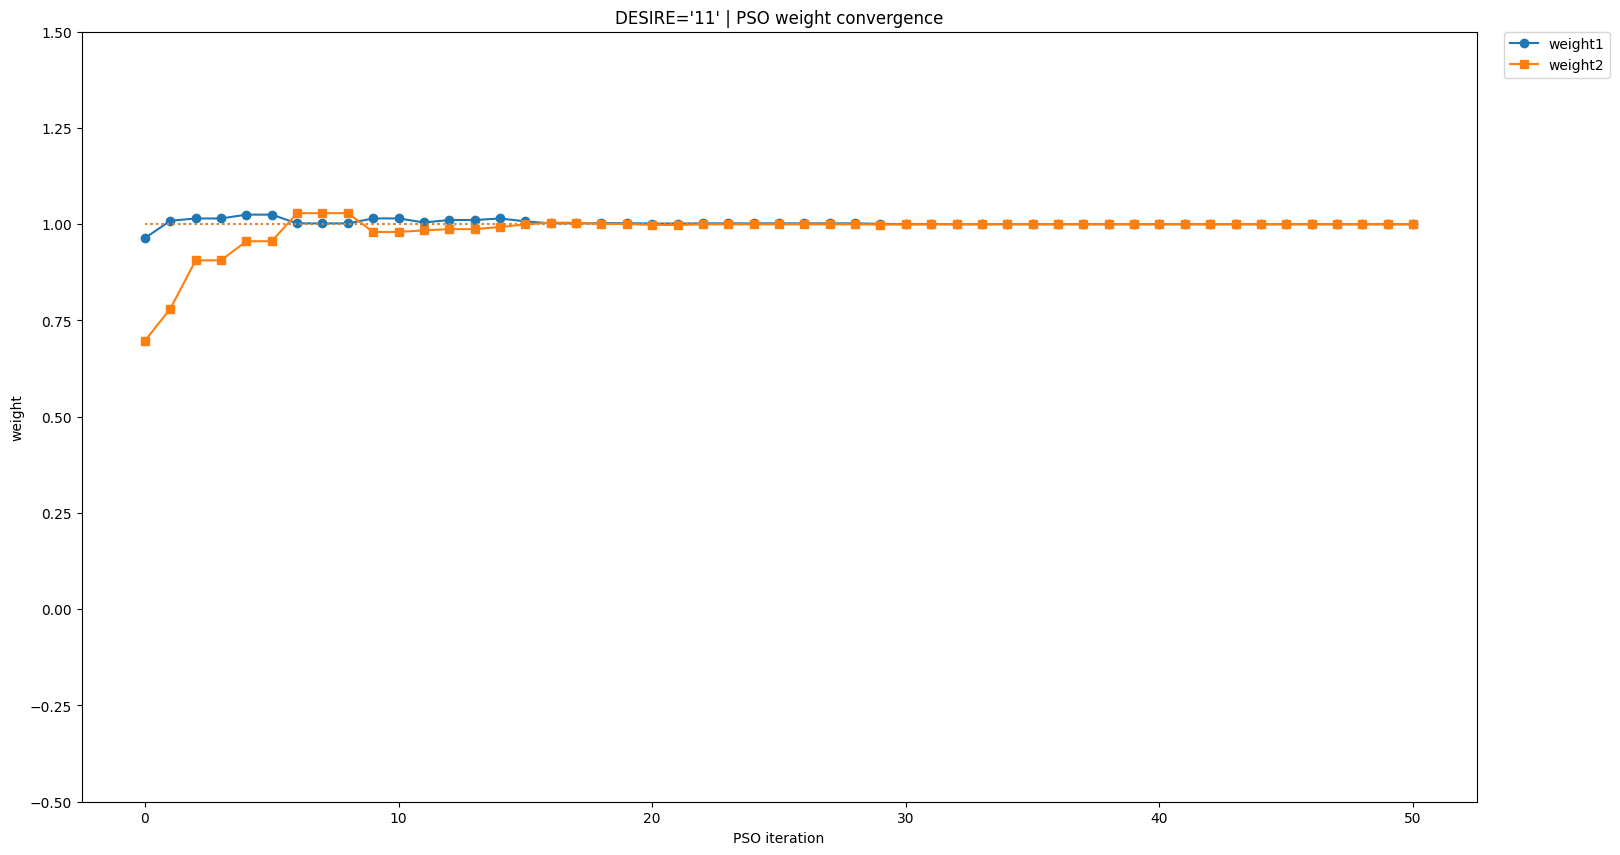

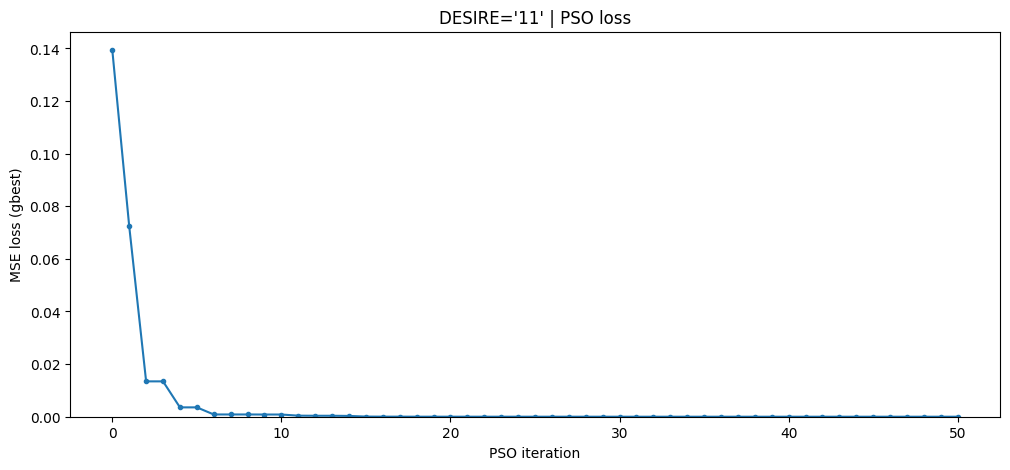

In [15]:
desire_11 = [1, 1]
plot_pso_weights(result_11['gbest_history'], desire_11, title="DESIRE='11' | PSO weight convergence")
plot_pso_loss(result_11['gbest_loss_history'], title="DESIRE='11' | PSO loss")

### Experiment 2: DESIRE='01' (the case gradient descent fails on)

In [16]:
data_01 = load_training_data('/content/thesis-edit-distance-nn/sampledata/desired_length_2_levenshtein_3.csv')

x0, y0, _ = data_01[0]
pairs_01 = transform_seqs_to_input(x0, y0)
SEQ_LEN_X_01 = len(x0)
SEQ_LEN_Y_01 = len(y0)
PAIRS_LEN_01 = len(pairs_01)

model_01 = align_model_for_N(SEQ_LEN_X_01, SEQ_LEN_Y_01, PAIRS_LEN_01)
set_weight_for_debug(model_01, SEQ_LEN_X_01, SEQ_LEN_Y_01, PAIRS_LEN_01)

print(f'Search space: {SEQ_LEN_Y_01} weights')
print(f'Training samples: {len(data_01)}')
print(f'Target weights (DESIRE): [0, 1]')

setting frozen weights ...
Search space: 2 weights
Training samples: 4
Target weights (DESIRE): [0, 1]


In [17]:
result_01 = pso_optimize(
    model_01, SEQ_LEN_Y_01, data_01,
    n_particles=N_PARTICLES, n_iterations=N_ITERATIONS,
    w_inertia=W_INERTIA, c1=C1, c2=C2,
    pos_min=POS_MIN, pos_max=POS_MAX,
    seed=SEED
)

print(f"\nFinal weights: {result_01['gbest_position']}")
print(f"Final loss: {result_01['gbest_fitness']:.6f}")

Iteration 0 | best loss: 0.054881 | best weights: [0.70223002 0.91614516]
Iteration 1 | best loss: 0.029043 | best weights: [-0.2061052   1.08833597]
Iteration 10 | best loss: 0.000077 | best weights: [0.01099756 1.00411193]
Iteration 20 | best loss: 0.000010 | best weights: [0.0029119  1.00233697]
Iteration 30 | best loss: 0.000001 | best weights: [4.11270829e-04 9.99336892e-01]
Iteration 40 | best loss: 0.000000 | best weights: [4.10300863e-04 1.00003151e+00]
Iteration 50 | best loss: 0.000000 | best weights: [-9.24626616e-05  1.00004194e+00]

Final weights: [-9.24626616e-05  1.00004194e+00]
Final loss: 0.000000


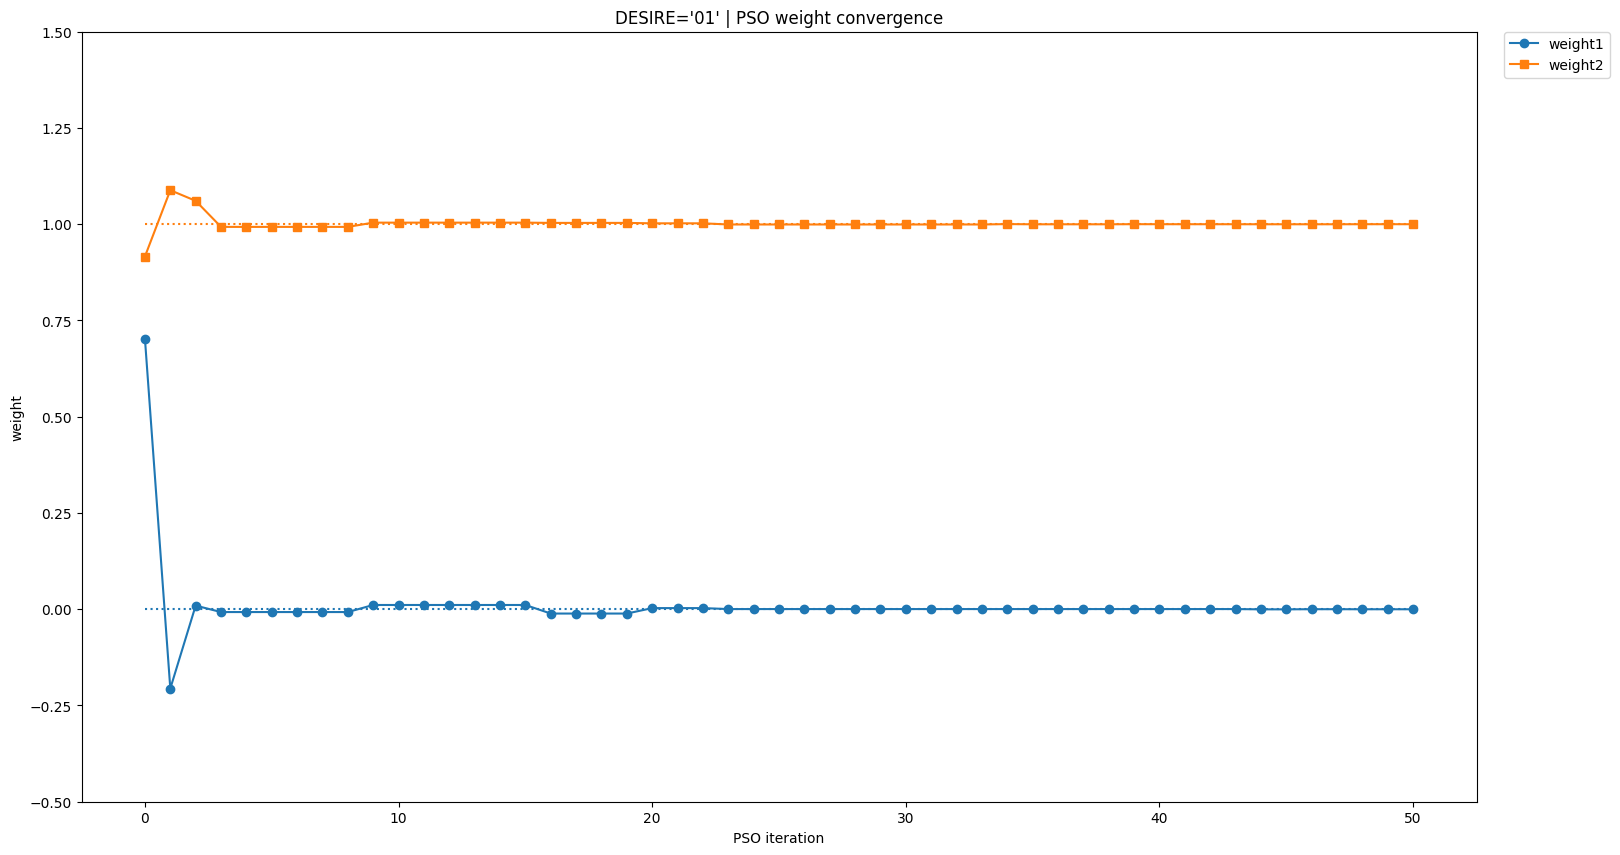

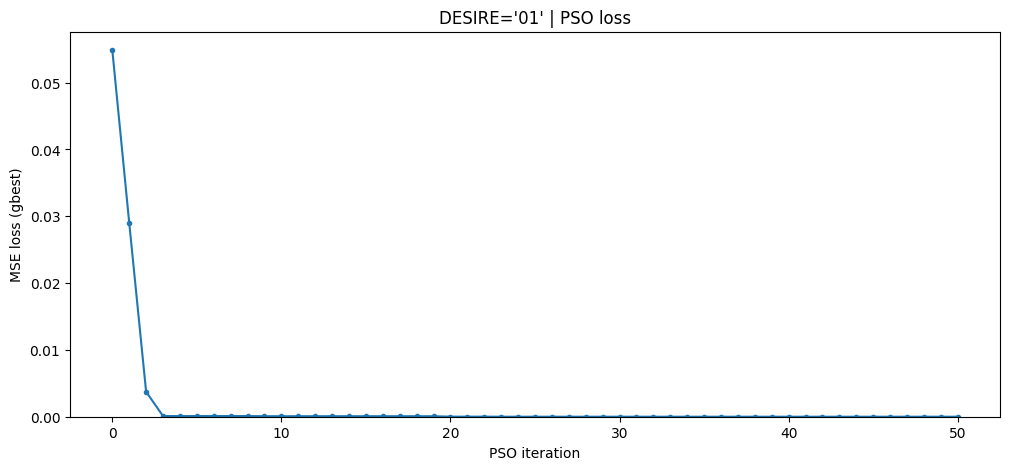

In [18]:
desire_01 = [0, 1]
plot_pso_weights(result_01['gbest_history'], desire_01, title="DESIRE='01' | PSO weight convergence")
plot_pso_loss(result_01['gbest_loss_history'], title="DESIRE='01' | PSO loss")

### Experiment 3: DESIRE='01011' (5-character case from colab2 / paper Figure 13)

This is the longer string case. The CSV doesn't exist in the repo, so we generate it on the fly using a standard Levenshtein implementation.

In [19]:
from itertools import product

def levenshtein(s1, s2):
    m, n = len(s1), len(s2)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1):
        dp[i][0] = i
    for j in range(n+1):
        dp[0][j] = j
    for i in range(1, m+1):
        for j in range(1, n+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1, dp[i-1][j-1]+cost)
    return dp[m][n]

def generate_desired_csv(desire, filename):
    n = len(desire)
    all_strings = [''.join(p) for p in product('01', repeat=n)]
    with open(filename, 'w') as f:
        for s in all_strings:
            dist = levenshtein(s, desire)
            f.write(f'{s},{desire},{dist}\n')

generate_desired_csv('01011', '/content/thesis-edit-distance-nn/sampledata/desired_length_5_levenshtein_2.csv')
print('done')
!cat /content/thesis-edit-distance-nn/sampledata/desired_length_5_levenshtein_2.csv

done
00000,01011,3
00001,01011,2
00010,01011,2
00011,01011,1
00100,01011,3
00101,01011,2
00110,01011,2
00111,01011,2
01000,01011,2
01001,01011,1
01010,01011,1
01011,01011,0
01100,01011,3
01101,01011,2
01110,01011,2
01111,01011,1
10000,01011,4
10001,01011,3
10010,01011,3
10011,01011,2
10100,01011,3
10101,01011,2
10110,01011,2
10111,01011,2
11000,01011,3
11001,01011,2
11010,01011,2
11011,01011,1
11100,01011,4
11101,01011,3
11110,01011,3
11111,01011,2


In [20]:
data_01011 = load_training_data('/content/thesis-edit-distance-nn/sampledata/desired_length_5_levenshtein_2.csv')

x0, y0, _ = data_01011[0]
pairs_01011 = transform_seqs_to_input(x0, y0)
SEQ_LEN_X_01011 = len(x0)
SEQ_LEN_Y_01011 = len(y0)
PAIRS_LEN_01011 = len(pairs_01011)

model_01011 = align_model_for_N(SEQ_LEN_X_01011, SEQ_LEN_Y_01011, PAIRS_LEN_01011)
set_weight_for_debug(model_01011, SEQ_LEN_X_01011, SEQ_LEN_Y_01011, PAIRS_LEN_01011)

print(f'Search space: {SEQ_LEN_Y_01011} weights')
print(f'Training samples: {len(data_01011)}')
print(f'Target weights (DESIRE): [0, 1, 0, 1, 1]')

setting frozen weights ...
Search space: 5 weights
Training samples: 32
Target weights (DESIRE): [0, 1, 0, 1, 1]


In [21]:
result_01011 = pso_optimize(
    model_01011, SEQ_LEN_Y_01011, data_01011,
    n_particles=N_PARTICLES, n_iterations=N_ITERATIONS,
    w_inertia=W_INERTIA, c1=C1, c2=C2,
    pos_min=POS_MIN, pos_max=POS_MAX,
    seed=SEED
)

print(f"\nFinal weights: {result_01011['gbest_position']}")
print(f"Final loss: {result_01011['gbest_fitness']:.6f}")

Iteration 0 | best loss: 0.251673 | best weights: [-0.26081151  0.92648957  1.0215701   0.6225544   1.04193436]
Iteration 1 | best loss: 0.036156 | best weights: [0.94038624 0.88049009 1.03237626 0.99014729 1.10244112]
Iteration 10 | best loss: 0.008787 | best weights: [0.92700797 1.04092159 1.06682442 0.98402019 1.02658785]
Iteration 20 | best loss: 0.000600 | best weights: [1.01123972 1.00011978 1.0300457  1.00867049 1.00163571]
Iteration 30 | best loss: 0.000218 | best weights: [0.98783188 0.99210666 0.99700214 0.99579003 1.00336482]
Iteration 40 | best loss: 0.000054 | best weights: [0.9996928  1.00469326 0.99373844 1.0011584  1.00089829]
Iteration 50 | best loss: 0.000018 | best weights: [0.99603061 1.00186723 0.99860643 0.99850719 1.00060292]

Final weights: [0.99603061 1.00186723 0.99860643 0.99850719 1.00060292]
Final loss: 0.000018


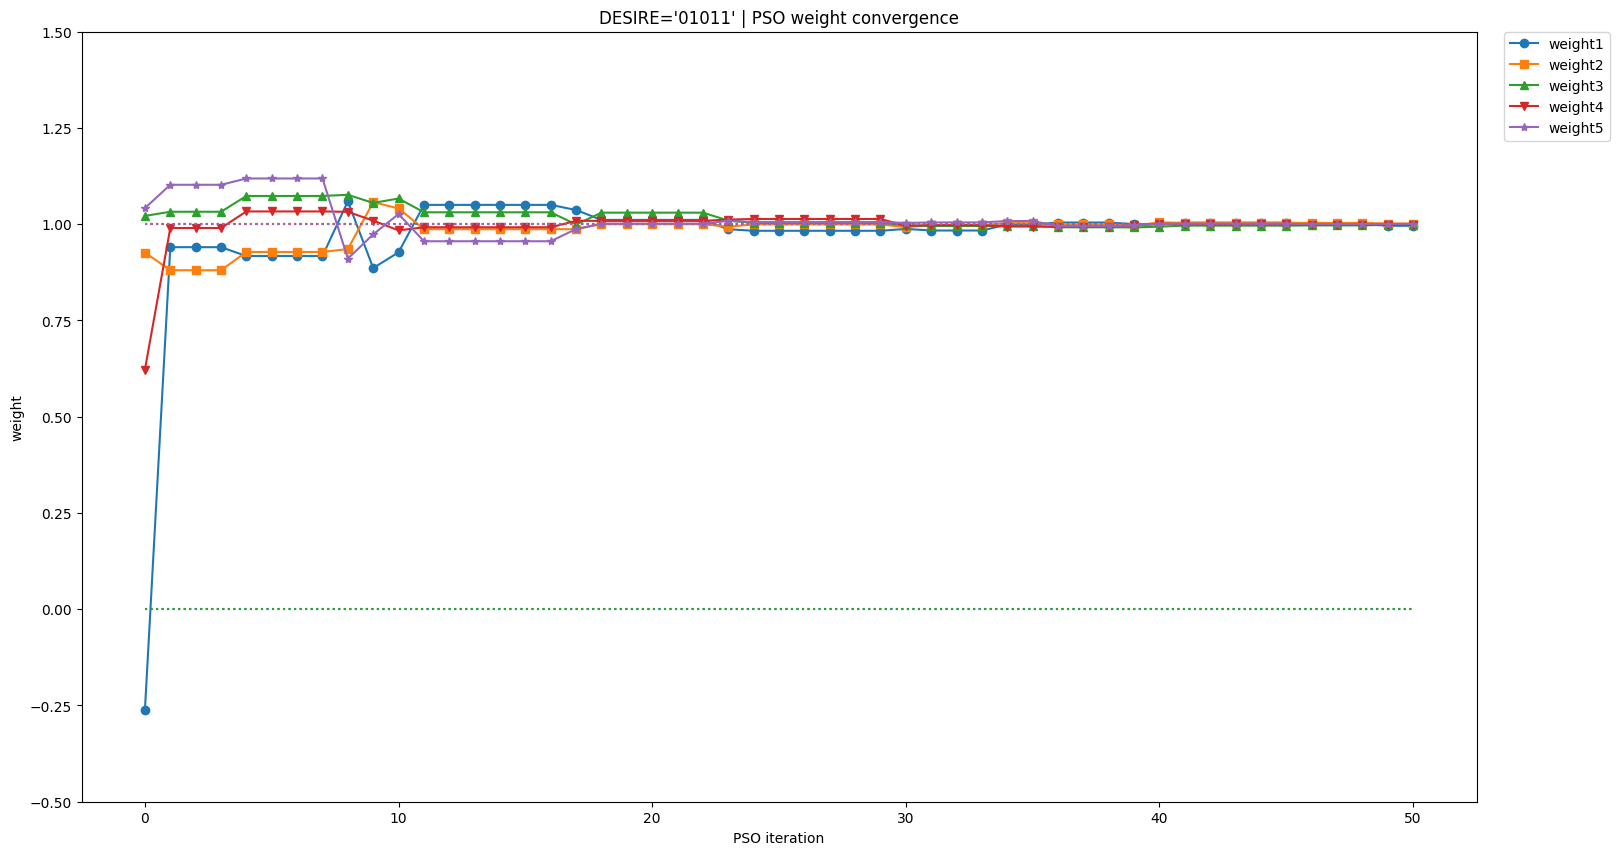

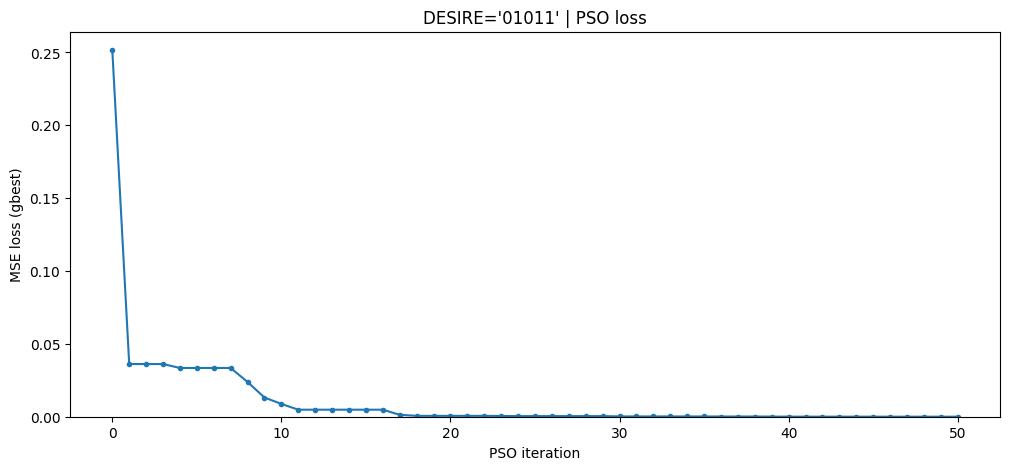

In [22]:
desire_01011 = [0, 1, 0, 1, 1]
plot_pso_weights(result_01011['gbest_history'], desire_01011, title="DESIRE='01011' | PSO weight convergence")
plot_pso_loss(result_01011['gbest_loss_history'], title="DESIRE='01011' | PSO loss")

### Side-by-side comparison

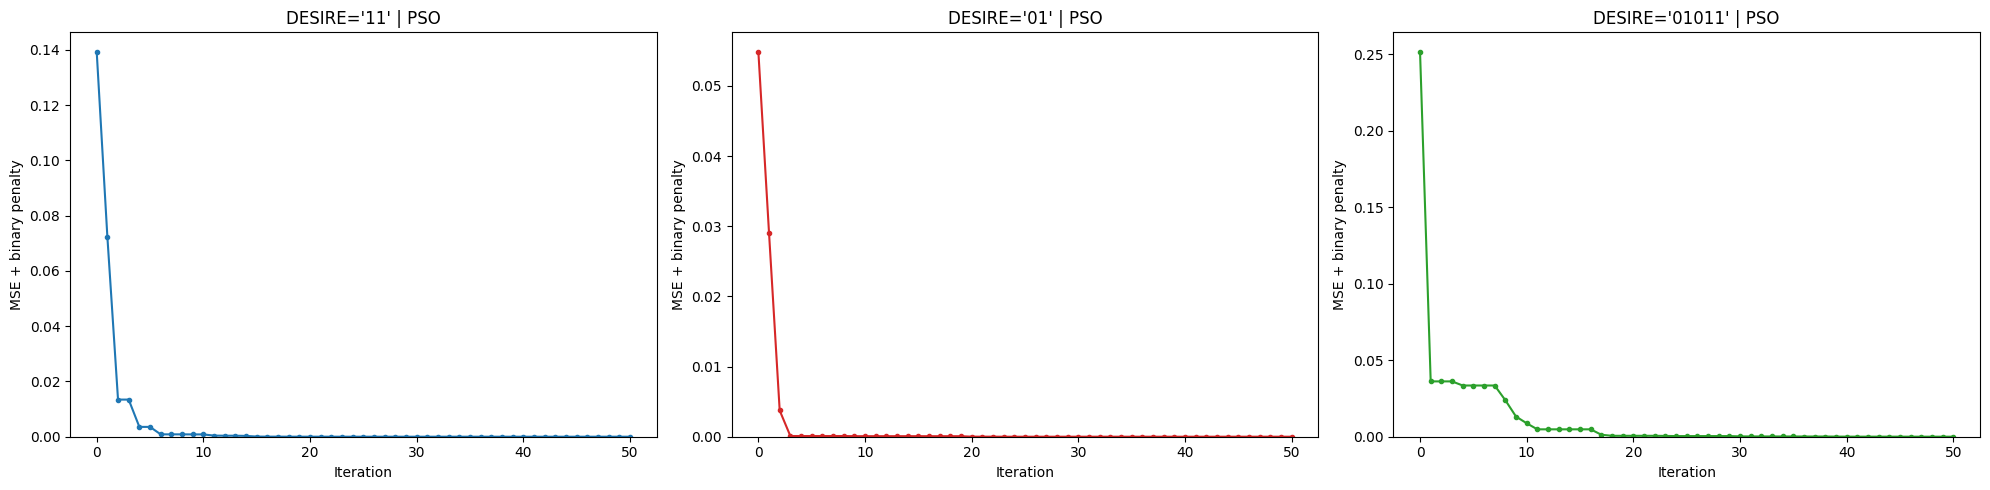

=== DESIRE=11 ===
  Target:  [1, 1]
  Found:   [0.99999748 0.99999896]
  Loss:    0.000000

=== DESIRE=01 ===
  Target:  [0, 1]
  Found:   [-9.24626616e-05  1.00004194e+00]
  Loss:    0.000000

=== DESIRE=01011 ===
  Target:  [0, 1, 0, 1, 1]
  Found:   [0.99603061 1.00186723 0.99860643 0.99850719 1.00060292]
  Loss:    0.000018


In [23]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

ax1.plot(result_11['gbest_loss_history'], marker='o', markersize=3)
ax1.set_title("DESIRE='11' | PSO")
ax1.set_xlabel('Iteration')
ax1.set_ylabel('MSE + binary penalty')
ax1.set_ylim(bottom=0)

ax2.plot(result_01['gbest_loss_history'], marker='o', markersize=3, color='#d62728')
ax2.set_title("DESIRE='01' | PSO")
ax2.set_xlabel('Iteration')
ax2.set_ylabel('MSE + binary penalty')
ax2.set_ylim(bottom=0)

ax3.plot(result_01011['gbest_loss_history'], marker='o', markersize=3, color='#2ca02c')
ax3.set_title("DESIRE='01011' | PSO")
ax3.set_xlabel('Iteration')
ax3.set_ylabel('MSE + binary penalty')
ax3.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

print('=== DESIRE=11 ===')
print(f"  Target:  [1, 1]")
print(f"  Found:   {result_11['gbest_position']}")
print(f"  Loss:    {result_11['gbest_fitness']:.6f}")
print()
print('=== DESIRE=01 ===')
print(f"  Target:  [0, 1]")
print(f"  Found:   {result_01['gbest_position']}")
print(f"  Loss:    {result_01['gbest_fitness']:.6f}")
print()
print('=== DESIRE=01011 ===')
print(f"  Target:  [0, 1, 0, 1, 1]")
print(f"  Found:   {result_01011['gbest_position']}")
print(f"  Loss:    {result_01011['gbest_fitness']:.6f}")